# Thesis Bot V0 

This is a very crude attempt at making a bot that can answer question from the
thesis, I created it in the followings way

1. Convert the PDF version of my thesis to markdown, ysing pymupdf
2. Use langchain to chunk it
3. Use sentence transformers to turn it into vector embeddings
4. Use those to find the context in the thesis based on the question. 

In [1]:
# Install required packages if not already installed
# !pip install voyageai python-dotenv

# Load environment variables from .env file
from dotenv import load_dotenv
import os

# Load .env file from the parent directory (since notebook is in notebooks/ folder)
load_dotenv('../.env')

print("Environment check:")
print(f"VOYAGE_API_KEY set: {'✅' if os.getenv('VOYAGE_API_KEY') else '❌'}")
print(f"ANTHROPIC_API_KEY set: {'✅' if os.getenv('ANTHROPIC_API_KEY') else '❌'}")

# Alternative: Set keys directly in notebook (less secure)
# os.environ['VOYAGE_API_KEY'] = 'your_key_here'
# os.environ['ANTHROPIC_API_KEY'] = 'your_key_here'



Environment check:
VOYAGE_API_KEY set: ✅
ANTHROPIC_API_KEY set: ✅


## Data preparation 

This is the data preparation step. We will read in the thesis and then break
into up into chunks and finally create vector embedings, which represent the
semantic meaning of the text. 



## Load the data

Load the data into

In [3]:
import pymupdf4llm
from langchain.text_splitter import MarkdownTextSplitter

# Get the MD text
md_text = pymupdf4llm.to_markdown("../data/raw/thesis.pdf")  # get markdown for all pages

In [4]:
splitter = MarkdownTextSplitter(chunk_size=1000, chunk_overlap=100)
documents = splitter.create_documents([md_text])
thesis_chunks = [doc.page_content for doc in documents]
print(f"Thesis split into {len(thesis_chunks)} meaningful chunks.")

Thesis split into 365 meaningful chunks.


## Create vector embeddings 

In [6]:
import voyageai
import numpy as np
import os

# Initialize Voyage AI client
# Make sure to set your VOYAGE_API_KEY environment variable
voyage_client = voyageai.Client()

# This assumes you have your 'thesis_chunks' variable from the last step
# thesis_chunks = [doc.page_content for doc in documents]

print("Generating embeddings using Voyage AI...")
print(f"Using model: voyage-3.5-lite")

# Generate embeddings for all your chunks using Voyage AI API
# This will be much faster and use no local memory for models!
result = voyage_client.embed(
    texts=thesis_chunks,
    model="voyage-3.5-lite",
    input_type="document"  # These are documents for retrieval
)

# Convert to numpy array (same format as before)
chunk_embeddings = np.array(result.embeddings)

# Check the result
print("\nEmbedding generation complete!")
print(f"Shape of the embeddings array: {chunk_embeddings.shape}")
print(f"Total tokens used: {result.total_tokens}")

# At this point, you have two crucial variables:
# 1. thesis_chunks      (a list of all your text chunks)  
# 2. chunk_embeddings   (a numpy array of corresponding vector embeddings)

# Note: Voyage AI models produce 1024-dimensional embeddings by default
# This is higher quality than the 384-dimensional sentence-transformers model!

Generating embeddings using Voyage AI...
Using model: voyage-3.5-lite

Embedding generation complete!
Shape of the embeddings array: (365, 1024)
Total tokens used: 96318


## Build the Chatbot Function

The plan is to use the users question then search the chunks using cosine
similarity. Build the prompt and finally call the API for the answer?

In [8]:
import numpy as np
import anthropic

# This assumes you have these variables from the previous steps:
# - embedding_model: Your loaded SentenceTransformer model
# - thesis_chunks: The list of your text chunks
# - chunk_embeddings: The numpy array of your chunk embeddings

# Make sure your Anthropic client is initialized
# Replace "YOUR_ANTHROPIC_API_KEY" with your actual key
YOUR_ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
try:
    client = anthropic.Anthropic(api_key=YOUR_ANTHROPIC_API_KEY)
except ImportError:
    print("Anthropic library not found. Please install it with 'pip install anthropic'")
    client = None


def find_most_similar_chunks(question_embedding, top_k=3):
    """
    Finds the top_k most similar chunks to a question embedding.
    """
    # Calculate cosine similarity between the question embedding and all chunk embeddings
    similarities = np.dot(chunk_embeddings, question_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_embedding))
    
    # Get the indices of the top_k most similar chunks
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    return top_indices

def find_relevant_chunks_with_threshold(question_embedding, similarity_threshold=0.75):
    """
    Finds all chunks with a similarity score above a certain threshold.
    """
    # Calculate cosine similarity
    similarities = np.dot(chunk_embeddings, question_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_embedding))
    
    # Find all indices where the similarity is above the threshold
    relevant_indices = np.where(similarities > similarity_threshold)[0]
    
    # Sort them by similarity score to present the most relevant ones first
    relevant_indices = relevant_indices[np.argsort(similarities[relevant_indices])[::-1]]
    
    print(f"   Found {len(relevant_indices)} chunks above the similarity threshold of {similarity_threshold}.")
    
    return relevant_indices

# You would then update your main function to call this new retrieval method.
# The rest of the answer_question_from_thesis function remains the same.


def answer_question_from_thesis(question):
    """
    Takes a user's question, retrieves relevant context from the thesis,
    and generates an answer using the Anthropic API.
    """
    if not client:
        return "Anthropic client not initialized. Please set your API key."

    print(f"-> User Question: {question}")

    # 1. Embed the user's question using Voyage AI
    print("   Embedding the question...")
    question_result = voyage_client.embed(
        texts=[question],
        model="voyage-3.5-lite", 
        input_type="query"  # This is a query for retrieval
    )
    question_embedding = np.array(question_result.embeddings[0])

    # 2. Find the most relevant chunks from the thesis
    print("   Searching for relevant chunks in the thesis...")
    relevant_chunk_indices = find_most_similar_chunks(question_embedding, top_k=3)
    #relevant_chunk_indices = find_relevant_chunks_with_threshold(question_embedding)
    print(" The number of relevant chunks {:d}".format(len(relevant_chunk_indices)))
    
    # 3. Create the context string from the top chunks
    context = "\n\n---\n\n".join([thesis_chunks[i] for i in relevant_chunk_indices])
    
    # 4. Construct the prompt for the LLM
    prompt = f"""You are an expert research assistant answering questions about a PhD thesis. 
    Your task is to answer the user's question based ONLY on the provided context below.
    If the context does not contain the answer, you must state that you cannot find the answer in the document.

    CONTEXT FROM THESIS:
    ---
    {context}
    ---

    USER'S QUESTION: {question}

    ANSWER:"""

    #print(prompt)

    # 5. Call the Anthropic API to get the final answer
    print("   Asking Claude to generate the final answer...")
    try:
        response = client.messages.create(
            model="claude-3-5-haiku-20241022",  # A powerful and cost-effective model
            max_tokens=1500,
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        final_answer = response.content[0].text
        print("-> Claude's Answer Received.")
        return final_answer
    except Exception as e:
        print(f"An error occurred with the Anthropic API: {e}")
        return "Sorry, I encountered an error trying to generate an answer."

# --- EXAMPLE USAGE ---
my_question = "What is the Feynmen-Y?"
answer = answer_question_from_thesis(my_question)

print("\n" + "="*20 + " FINAL ANSWER " + "="*20)
print(answer)
print("="*54)

-> User Question: What is the Feynmen-Y?
   Embedding the question...
   Searching for relevant chunks in the thesis...
 The number of relevant chunks 3
   Asking Claude to generate the final answer...
-> Claude's Answer Received.

==================== FINAL ANSWER ====================
Based on the provided context, the Feynman-Y (or variance-over-mean technique) is a method developed by Richard Feynman to analyze neutron count fluctuations. Key points include:

1. Purpose: It examines the deviation of neutron counts from a Poisson distribution by quantifying excess variance caused by correlated counts from fission chains.

2. Mathematical Definition: The technique is expressed by the equation:
   
   (variance/mean) = 1 + Y

3. Operational Characteristics:
- Measures the number of counts in a gate
- Gates are opened through clock triggers, not detector events
- Allows for creating Feynman-Y histograms that visually represent deviations from expected Poisson statistics

4. Applications

## Experiments with exapanding context 

This is an experiment with expanding the context of a question to better search
the thesis 

In [ ]:
def expand_context(question):
    """
    Uses an LLM to expand the question and provide better context.
    """
    # use Voyage AI to create question embeddings
    question_result = voyage_client.embed(
        texts=[question],
        model="voyage-3.5-lite",
        input_type="query"
    )
    question_embedding = np.array(question_result.embeddings[0])
    # get initial seed context
    relevant_chunk_indices = find_most_similar_chunks(question_embedding, top_k=3)
    # 3. Create the context string from the top chunks
    context = "\n\n---\n\n".join([thesis_chunks[i] for i in relevant_chunk_indices])

    print("   Generating a hypothetical document (HyDE)...")
    
    prompt = f"""You are a research assistant creating a hypothetical thesis excerpt to find relevant information. 
    Based on the user's question, generate a short, dense, academic-style
    passage that contains a plausible answer. I have given you some context from the thesis as a start. 

    CONTEXT FROM THESIS:
    ---
    {context}
    ---

    User Question: "{question}"

    Hypothetical Thesis Excerpt:"""

    try:
        response = client.messages.create(
            model="claude-3-5-haiku-20241022",
            max_tokens=300,
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        hypothetical_doc = response.content[0].text
        print(f"   -> Generated HyDE Document: {hypothetical_doc}")
        return hypothetical_doc
    except Exception as e:
        print(f"   HyDE generation failed: {e}")
        # If HyDE fails, we fall back to just using the original question.
        return question


question = "What are the limits of 3D imaging technique used in this thesis?"
question_expanded = expand_context(question)


# Use Voyage AI to embed the expanded question
expanded_result = voyage_client.embed(
    texts=[question_expanded],
    model="voyage-3.5-lite",
    input_type="query"
)


   Generating a hypothetical document (HyDE)...
   -> Generated HyDE Document: Here's a plausible academic-style excerpt addressing the limits of 3D imaging technique:

The γ-n-n 3D imaging technique, while promising, encounters several fundamental limitations inherent to its methodological approach. Primarily, the technique's spatial resolution is constrained by three critical factors: detector solid angle coverage, energy resolution of scintillation detectors, and the statistical uncertainty associated with neutron scatter events. The method's efficiency is directly proportional to the detector's angular acceptance, necessitating extensive geometric configuration to achieve meaningful reconstructions.

Moreover, the proton recoil energy measurement introduces significant uncertainty, particularly at low energy scales typical of organic scintillators. Current empirical fitting methods for light output response provide only approximate estimations, fundamentally restricting the precisi

In [13]:
question_result = voyage_client.embed(
        texts=[question],
        model="voyage-3.5-lite",
        input_type="query"
    )
question_embedding = np.array(question_result.embeddings[0])


question_expanded_embedding = np.array(expanded_result.embeddings[0])
similarities = np.dot(chunk_embeddings, question_expanded_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_expanded_embedding))

similarities_question = np.dot(chunk_embeddings, question_embedding) / (np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(question_embedding))

(array([ 7., 20., 53., 75., 88., 50., 31., 20., 16.,  5.]),
 array([0.16886138, 0.20815942, 0.24745746, 0.2867555 , 0.32605355,
        0.36535159, 0.40464963, 0.44394768, 0.48324572, 0.52254376,
        0.5618418 ]),
 <BarContainer object of 10 artists>)

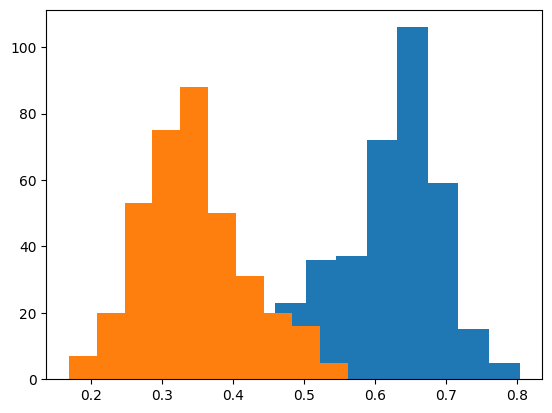

In [14]:
import matplotlib.pyplot as plt

plt.hist(similarities)
plt.hist(similarities_question)